In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns, calculate_relative_volume
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats
import statsmodels.api as sm
from utils.helpers import constrained_linear_regression, gmean, hmean, compute_r2, normalize_weights



# UTILITY FUNCTIONS

# Parameters

In [25]:
LOOKFORWARD_PERIOD = 21
REBALANCE_PERIOD = 21
LOOKBACK_PERIODS=[21, 100, 252]
LAG_PERIODS = [0, 21]
CURRENT_CAPITAL = 87503


COVAR_LOOKBACK_PERIOD = 252
HISTORY_LOOKBACK_PERIOD = 252 * 2

CURRENT_DATE = datetime.datetime.now().date()
CURRENT_DATE = CURRENT_DATE.strftime("%Y%m%d")

# Load Data

In [26]:
tickers_to_fetch = [
    'IB01.L', 
    'SHV', 
    'SPY', 
    'TLT', 
    'GLD', 
    '^VIX', 
    '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO', 
    'CPER', 
    'OPEN',
    'UURAF',
    'UUUU',
    'ABAT',
    'LAC',
    'TMC',
    'MP',
    'UPRO',
    'TMF',
    'CSPX.L',
    'U',
    'SMR',
    'OKLO',
    'LEU',
    'BWXT',
    'GOOG',
    'MSFT',
    'SHNY',
    'HOOD',
    'ETHA',
]

fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)

for ticker in price_data:
    print(ticker, price_data[ticker].index.to_list()[0], price_data[ticker].index.to_list()[-1])
    # display(price_data[ticker])

2025-10-15 10:44:06,591 - utils.data_fetcher - INFO - Loading data for ['IB01.L', 'SHV', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA', 'DBA', 'EEM', 'LQD', 'IBIT', 'USO', 'CPER', 'OPEN', 'UURAF', 'UUUU', 'ABAT', 'LAC', 'TMC', 'MP', 'UPRO', 'TMF', 'CSPX.L', 'U', 'SMR', 'OKLO', 'LEU', 'BWXT', 'GOOG', 'MSFT', 'SHNY', 'HOOD', 'ETHA']
2025-10-15 10:44:06,593 - utils.data_fetcher - INFO - Data for IB01.L already exists
2025-10-15 10:44:06,595 - utils.data_fetcher - INFO - Data for SHV already exists
2025-10-15 10:44:06,596 - utils.data_fetcher - INFO - Data for SPY already exists
2025-10-15 10:44:06,598 - utils.data_fetcher - INFO - Data for TLT already exists
2025-10-15 10:44:06,600 - utils.data_fetcher - INFO - Data for GLD already exists
2025-10-15 10:44:06,602 - utils.data_fetcher - INFO - Data for ^VIX already exists
2025-10-15 10:44:06,604 - utils.data_fetcher - INFO - Data for ^GVZ already exists
2025-10-15 10:44:06,606 - utils.data_fetcher - INFO - Data for PPLT already exists


IB01.L 2019-02-20 00:00:00 2025-10-14 00:00:00
SHV 2007-01-11 00:00:00 2025-10-14 00:00:00
SPY 1993-01-29 00:00:00 2025-10-14 00:00:00
TLT 2002-07-30 00:00:00 2025-10-14 00:00:00
GLD 2004-11-18 00:00:00 2025-10-14 00:00:00
^VIX 1990-01-02 00:00:00 2025-10-14 00:00:00
^GVZ 2008-06-03 00:00:00 2025-10-14 00:00:00
PPLT 2010-01-08 00:00:00 2025-10-14 00:00:00
URA 2010-11-05 00:00:00 2025-10-14 00:00:00
DBA 2007-01-05 00:00:00 2025-10-14 00:00:00
EEM 2003-04-14 00:00:00 2025-10-14 00:00:00
LQD 2002-07-30 00:00:00 2025-10-14 00:00:00
IBIT 2024-01-11 00:00:00 2025-10-14 00:00:00
USO 2006-04-10 00:00:00 2025-10-14 00:00:00
CPER 2011-11-15 00:00:00 2025-10-14 00:00:00
OPEN 2020-06-18 00:00:00 2025-10-14 00:00:00
UURAF 2010-01-05 00:00:00 2025-10-14 00:00:00
UUUU 2007-03-19 00:00:00 2025-10-14 00:00:00
ABAT 2016-02-24 00:00:00 2025-10-14 00:00:00
LAC 2023-10-02 00:00:00 2025-10-14 00:00:00
TMC 2021-09-10 00:00:00 2025-10-14 00:00:00
MP 2020-06-22 00:00:00 2025-10-14 00:00:00
UPRO 2009-06-25 00:0

# Current Portfolio

CAGR:                   17.19%
Volatility:             8.56%
Sharpe Ratio:           2.01
Max Drawdown:          -3.24%
Total Returns:          13.06%
Total PnL:             $10258.82


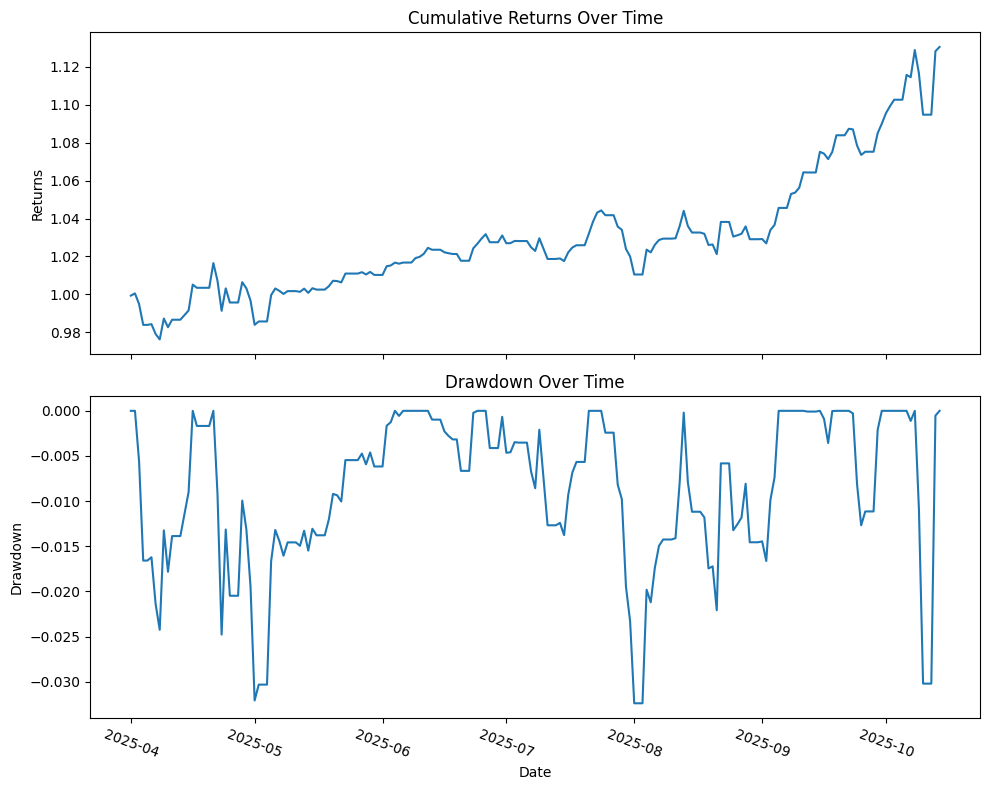

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital, holdings

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    print(f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values)
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')
# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = {
    'UPRO': pd.read_pickle(f'./data/raw/price/UPRO_{CURRENT_DATE}.pkl'),
    'SPY': pd.read_pickle(f'./data/raw/price/SPY_{CURRENT_DATE}.pkl'),
    'TLT': pd.read_pickle(f'./data/raw/price/TLT_{CURRENT_DATE}.pkl'),
    'GLD': pd.read_pickle(f'./data/raw/price/GLD_{CURRENT_DATE}.pkl'),
    'SHV': pd.read_pickle(f'./data/raw/price/SHV_{CURRENT_DATE}.pkl'),
    'PPLT': pd.read_pickle(f'./data/raw/price/PPLT_{CURRENT_DATE}.pkl'),
    'URA': pd.read_pickle(f'./data/raw/price/URA_{CURRENT_DATE}.pkl'),
    'USO': pd.read_pickle(f'./data/raw/price/USO_{CURRENT_DATE}.pkl'),
    'IBIT': pd.read_pickle(f'./data/raw/price/IBIT_{CURRENT_DATE}.pkl'),
    'EEM': pd.read_pickle(f'./data/raw/price/EEM_{CURRENT_DATE}.pkl'),
    'DBA': pd.read_pickle(f'./data/raw/price/DBA_{CURRENT_DATE}.pkl'),
    'IB01.L': pd.read_pickle(f'./data/raw/price/IB01.L_{CURRENT_DATE}.pkl'),
    'LQD': pd.read_pickle(f'./data/raw/price/LQD_{CURRENT_DATE}.pkl'),
    'CPER': pd.read_pickle(f'./data/raw/price/CPER_{CURRENT_DATE}.pkl'),
    'UUUU': pd.read_pickle(f'./data/raw/price/UUUU_{CURRENT_DATE}.pkl'),
    'ABAT': pd.read_pickle(f'./data/raw/price/ABAT_{CURRENT_DATE}.pkl'),
    'TMF': pd.read_pickle(f'./data/raw/price/TMF_{CURRENT_DATE}.pkl'),
    'CSPX.L': pd.read_pickle(f'./data/raw/price/CSPX.L_{CURRENT_DATE}.pkl'),
    'U': pd.read_pickle(f'./data/raw/price/U_{CURRENT_DATE}.pkl'),
    'SMR': pd.read_pickle(f'./data/raw/price/SMR_{CURRENT_DATE}.pkl'),
    'OKLO': pd.read_pickle(f'./data/raw/price/OKLO_{CURRENT_DATE}.pkl'),
    'LEU': pd.read_pickle(f'./data/raw/price/LEU_{CURRENT_DATE}.pkl'),
    'BWXT': pd.read_pickle(f'./data/raw/price/BWXT_{CURRENT_DATE}.pkl'),
    'GOOG': pd.read_pickle(f'./data/raw/price/GOOG_{CURRENT_DATE}.pkl'),
    'MSFT': pd.read_pickle(f'./data/raw/price/MSFT_{CURRENT_DATE}.pkl'),
    'HOOD': pd.read_pickle(f'./data/raw/price/HOOD_{CURRENT_DATE}.pkl'),
    'SHNY': pd.read_pickle(f'./data/raw/price/SHNY_{CURRENT_DATE}.pkl'),
    'ETHA': pd.read_pickle(f'./data/raw/price/ETHA_{CURRENT_DATE}.pkl'),
}
port_val, invested_cap, holdings = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap)
plot_portfolio_and_drawdown(port_val, invested_cap)
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')




In [28]:
current_holdings = {
    ticker: holdings[ticker].iloc[-1] for ticker in holdings if holdings[ticker].iloc[-1] != 0
}

current_holdings
df_view = pd.DataFrame.from_dict(current_holdings, orient='index', columns=['quantity'])
df_view['price'] = [price_data_dict[ticker]['close'].iloc[-1] for ticker in df_view.index]
df_view['value'] = df_view['quantity'] * df_view['price']
df_view['% of portfolio'] = df_view['value'] / CURRENT_CAPITAL * 100
df_view.sort_values('value', ascending=False, inplace=True)
print(f"% of portfolio: {sum(df_view['% of portfolio']):.2f}%")
df_view

% of portfolio: 104.73%


,quantity,price,value,% of portfolio
LQD,181.0,112.099998,20290.099724,23.187890
UPRO,167.0,108.760002,18162.920357,20.756912
SHNY,75.0,126.959999,9521.999931,10.881913
SPY,13.0,662.229980,8608.989746,9.838508
TLT,92.0,90.860001,8359.120056,9.552953
CSPX.L,10.0,708.200012,7082.000122,8.093437
GLD,18.0,380.790009,6854.220154,7.833126
EEM,89.0,52.970001,4714.330109,5.387621
URA,29.0,56.959999,1651.839973,1.887752
MSFT,3.0,513.570007,1540.710022,1.760751


# Portfolio Settings

In [29]:
# CORE PORTFOLIO
core_portfolio_ticker_list = [
    'CSPX.L',
    'LQD',
    'TLT',
    'EEM',
    'GLD',
]
core_portfolio_allocation = 0.5

SPY_mom_allocation = 0.1

leveraged_portfolio_orders = dict()
UPRO_vol_allocation = 0.2
SHNY_vol_allocation = 0.1


# STOCK-PICK PORTFOLIO
stock_pick_portfolio_ticker_list = [
    'URA', 
    'ETHA',
    'U',     
    'OKLO',
    'GOOG',
    'MSFT',
    'HOOD',
]
stock_pick_portfolio_allocation = 0.1

assert 0.99 < np.sum([
    core_portfolio_allocation,
    SPY_mom_allocation,
    UPRO_vol_allocation,
    SHNY_vol_allocation,
    stock_pick_portfolio_allocation,
]) < 1.01, "Allocations must sum to 1"

combined_target_allocation = dict()
combined_orders = dict()

# CORE PORTFOLIO

## Allocation based on HRP

### Utility Function

In [30]:
def allocation_func(
    ticker_list,
    data,
    historical_period, 
    current_date,
    covariance_matrix_lookback,
    verbose=False
):
    #################################################################
    # Correlation Optimization
    # Use HRP to optimize for correlation between assets
    #################################################################
    
    df_combined = pd.DataFrame()
    for ticker in ticker_list:
        df_data = data[ticker].copy()
        df_data = df_data[df_data.index <= current_date].copy()
        df_data = df_data.iloc[-historical_period:]
        df_data['returns'] = df_data['close'].pct_change()
        df_combined[ticker] = df_data['returns']
    df_combined.dropna(inplace=True)

    # Covariance Matrix with Exponentially Weighted Moving Average
    ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)
    
    # Convariance Matrix with Ledoit Wolf shrinkage
    ledoit_wolf_cov = risk_models.CovarianceShrinkage(
        prices=df_combined.iloc[-covariance_matrix_lookback:], 
        returns_data=True
    ).ledoit_wolf()

    # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
    cov = (ledoit_wolf_cov + ewma_cov) / 2

    # HRP to generate asset allocation weights
    hrpopt = HRPOpt(
        cov_matrix=cov
    )
    asset_allocation_weights = hrpopt.optimize()
    if verbose:
        for ticker in asset_allocation_weights:
            print(f"{ticker}: {asset_allocation_weights[ticker]:.2%}")
    

    


    #################################################################
    # Combination of all optimizations
    #################################################################
    final_weights = asset_allocation_weights

    return final_weights



### Get Allocation

In [31]:
allocations = allocation_func(
    core_portfolio_ticker_list,
    price_data,
    historical_period=252*2, 
    current_date=CURRENT_DATE,
    covariance_matrix_lookback=COVAR_LOOKBACK_PERIOD,
    verbose=True,
)

allocations

CSPX.L: 13.31%
EEM: 10.89%
GLD: 14.78%
LQD: 44.17%
TLT: 16.85%


OrderedDict([('CSPX.L', np.float64(0.13306442455200804)),
             ('EEM', np.float64(0.10885019315620448)),
             ('GLD', np.float64(0.1478489879710492)),
             ('LQD', np.float64(0.4416998146697032)),
             ('TLT', np.float64(0.16853657965103505))])

### Allocate

In [32]:
capital = core_portfolio_allocation * CURRENT_CAPITAL
core_portfolio_orders = dict()

for ticker in core_portfolio_ticker_list:
    print('-----------------------')
    print(ticker)

    # Current holding
    current_holding = current_holdings.get(ticker, 0)

    # Proposed capital
    capital_allocated = allocations[ticker] * capital
    
    current_price = price_data[ticker]['close'].iloc[-1]
    
    target_holding = int(capital_allocated / current_price)
    combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL

    # Proposed order
    target_order = int((target_holding - current_holding) * 0.75) + 1

    print(f"Capital_allocated = {capital_allocated:.2f} ({allocations[ticker]:.2%})")
    print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
    print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

    core_portfolio_orders[ticker] = target_order
    combined_orders[ticker] = target_order
    


-----------------------
CSPX.L
Capital_allocated = 5821.77 (13.31%)
Target holding:   = 8      (5821.77 / 708.20)
Target order:     = 0     (8 - 10.0)
-----------------------
LQD
Capital_allocated = 19325.03 (44.17%)
Target holding:   = 172      (19325.03 / 112.10)
Target order:     = -5     (172 - 181.0)
-----------------------
TLT
Capital_allocated = 7373.73 (16.85%)
Target holding:   = 81      (7373.73 / 90.86)
Target order:     = -7     (81 - 92.0)
-----------------------
EEM
Capital_allocated = 4762.36 (10.89%)
Target holding:   = 89      (4762.36 / 52.97)
Target order:     = 1     (89 - 89.0)
-----------------------
GLD
Capital_allocated = 6468.61 (14.78%)
Target holding:   = 16      (6468.61 / 380.79)
Target order:     = 0     (16 - 18.0)


# LEVERAGED PORTFOLIO

## Processing

In [33]:
import json

def rolling_percentile_rank(x):
    """Compute percentile rank of the last element within the window (excluding itself)."""
    if len(x) < 2:
        return np.nan
    current_val = x.iloc[-1]
    prev_vals = x.iloc[:-1]
    return (prev_vals < current_val).mean()

def process_data_for_leveraged_trades(
    lev_df,
    vix_df
):
    vix_df = vix_df.copy()
    df = lev_df.copy()
    df['returns'] = df['adjclose'].pct_change().fillna(0.0)
    df['cum_ret'] = df['adjclose'].expanding().apply(lambda x: x.iloc[-1] / x.iloc[0])
    df['drawdown'] = df['cum_ret'] / df['cum_ret'].cummax() - 1
    df['vix'] = vix_df['close']
    df['vix_change'] = df['vix'].rolling(21).apply(lambda x: x.iloc[-1] - x.iloc[0])
    df['vix_signal'] = (df['vix_change'].rolling(252).apply(rolling_percentile_rank) * 2).clip(lower=0, upper=1)
    
    with open('STATUS_leveraged_port.json', 'r') as f:
        status = json.load(f)
    return df, status
    
    

## UPRO

In [34]:
ticker = "UPRO"
lev_df = price_data[ticker]
vix_df = price_data['^VIX']
df, status = process_data_for_leveraged_trades(lev_df, vix_df)

signal = df['vix_signal'].iloc[-1]
drawdown = df['drawdown'].iloc[-1]
print(status)
if drawdown < 0.1 and (not status[ticker]):
    signal = 0.5 * signal
    status[ticker] = True
else: 
    status[ticker] = False

with open('STATUS_leveraged_port.json', 'w') as f:
    json.dump(status, f, indent=4)
print(status)
display(df.tail(5))




capital = UPRO_vol_allocation * CURRENT_CAPITAL



print('-----------------------')
print(ticker)

# Current holding
current_holding = current_holdings.get(ticker, 0)

# Proposed capital
capital_allocated = df['vix_signal'].iloc[-1] * capital

current_price = price_data[ticker]['close'].iloc[-1]

target_holding = int(capital_allocated / current_price)

# Proposed order
target_order = target_holding - current_holding

print(f"Capital_allocated = {capital_allocated:.2f} ({df['vix_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

leveraged_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order


{'UPRO': False, 'SHNY': False}
{'UPRO': True, 'SHNY': False}


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_ret,drawdown,vix,vix_change,vix_signal
Date,,,,,,,,,,,,,,,
2025-10-08,113.389999,114.830002,112.940002,114.779999,114.779999,2993900,0.0,0.0,0.0,0.017283,100.849801,0.000000,16.299999,0.949999,1.0
2025-10-09,114.970001,115.190002,112.769997,113.790001,113.790001,3089800,0.0,0.0,0.0,-0.008625,99.979954,-0.008625,16.430000,1.720000,1.0
2025-10-10,114.160004,115.059998,104.349998,104.489998,104.489998,6745100,0.0,0.0,0.0,-0.081730,91.808639,-0.089650,21.660000,6.900000,1.0
2025-10-13,108.070000,109.980003,107.650002,109.239998,109.239998,5053100,0.0,0.0,0.0,0.045459,95.982159,-0.048266,19.030001,3.340001,1.0
2025-10-14,106.290001,110.559998,104.300003,108.760002,108.760002,6488100,0.0,0.0,0.0,-0.004394,95.560417,-0.052448,20.809999,4.449999,1.0


-----------------------
UPRO
Capital_allocated = 17500.60 (100.00%)
Target holding:   = 160      (17500.60 / 108.76)
Target order:     = -7.0     (160 - 167.0)


## SHNY TRADE

In [35]:
ticker = "SHNY"
lev_df = price_data[ticker]
vix_df = price_data['^GVZ']
df, status = process_data_for_leveraged_trades(lev_df, vix_df)

signal = df['vix_signal'].iloc[-1]
drawdown = df['drawdown'].iloc[-1]
print(status)
if drawdown < 0.1 and (not status[ticker]):
    signal = 0.5 * signal
    status[ticker] = True
else:
    status[ticker] = False

with open('STATUS_leveraged_port.json', 'w') as f:
    json.dump(status, f, indent=4)
print(status)
display(df.tail(5))




capital = SHNY_vol_allocation * CURRENT_CAPITAL


print('-----------------------')
print(ticker)

# Current holding
current_holding = current_holdings.get(ticker, 0)

# Proposed capital
capital_allocated = df['vix_signal'].iloc[-1] * capital

current_price = price_data[ticker]['close'].iloc[-1]

target_holding = int(capital_allocated / current_price)

# Proposed order
target_order = target_holding - current_holding

print(f"Capital_allocated = {capital_allocated:.2f} ({df['vix_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}      ({target_holding} - {current_holding})")

leveraged_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order


{'UPRO': True, 'SHNY': False}
{'UPRO': True, 'SHNY': True}


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_ret,drawdown,vix,vix_change,vix_signal
Date,,,,,,,,,,,,,,,
2025-10-08,118.589996,120.330002,117.070000,119.120003,119.120003,247800,0.0,0.0,0.0,0.048222,4.848189,0.000000,21.809999,4.439999,1.0
2025-10-09,119.510002,119.809998,110.400002,112.540001,112.540001,266700,0.0,0.0,0.0,-0.055238,4.580383,-0.055238,21.850000,5.370001,1.0
2025-10-10,114.320000,116.809998,112.629997,116.019997,116.019997,225800,0.0,0.0,0.0,0.030922,4.722019,-0.026024,23.780001,7.400002,1.0
2025-10-13,122.589996,124.955002,121.847000,124.129997,124.129997,239700,0.0,0.0,0.0,0.069902,5.052096,0.000000,24.530001,6.630001,1.0
2025-10-14,124.000000,128.149994,123.980003,126.959999,126.959999,219600,0.0,0.0,0.0,0.022799,5.167277,0.000000,26.110001,7.740000,1.0


-----------------------
SHNY
Capital_allocated = 8750.30 (100.00%)
Target holding:   = 68      (8750.30 / 126.96)
Target order:     = -7.0      (68 - 75.0)


# MOMENTUM TRADE

In [36]:
def process_data_for_momentum_trades(
    df
):
    # Calculate indicators
    df['returns'] = df['adjclose'].pct_change().fillna(0.0)
    df['cum_returns'] = (1 + df['returns']).cumprod() - 1
    df['vol_21'] = df['returns'].rolling(window=21).std() * np.sqrt(252)
    df['roll_returns_252'] = df['returns'].rolling(window=252).apply(lambda x: np.prod(x + 1)) - 1
    df['roll_returns_lag_21'] = df['roll_returns_252'].shift(21)
    df['mom_signal'] = np.where(df['roll_returns_lag_21'] > 0, 1.0, 0.2)
    df['mom_signal'] = df['mom_signal'].fillna(1.0)
    df['drawdown'] = (df['cum_returns'] - df['cum_returns'].cummax()) / df['cum_returns'].cummax()

    df = df.copy()
    return df

ticker = "SPY"
df = price_data[ticker].copy()
df = process_data_for_momentum_trades(df)
display(df.tail(5))

capital = SPY_mom_allocation * CURRENT_CAPITAL
momentum_portfolio_orders = dict()
print('-----------------------')
print(ticker)
# Current holding
current_holding = current_holdings.get(ticker, 0)
# Proposed capital
capital_allocated = df['mom_signal'].iloc[-1] * capital
current_price = price_data[ticker]['close'].iloc[-1]
target_holding = int(capital_allocated / current_price)
# Proposed order
target_order = target_holding - current_holding
print(f"Capital_allocated = {capital_allocated:.2f} ({df['mom_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}      ({target_holding} - {current_holding})")
momentum_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order
    

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_returns,vol_21,roll_returns_252,roll_returns_lag_21,mom_signal,drawdown
Date,,,,,,,,,,,,,,,,
2025-10-08,670.250000,673.210022,669.419983,673.109985,673.109985,60702200,0.0,0.0,0.0,0.005963,26.685143,0.061744,0.189035,0.197995,1.0,0.000000
2025-10-09,673.530029,673.940002,669.210022,671.159973,671.159973,66501900,0.0,0.0,0.0,-0.002897,26.604939,0.063658,0.196407,0.222025,1.0,-0.003006
2025-10-10,672.130005,673.950012,652.840027,653.020020,653.020020,159422600,0.0,0.0,0.0,-0.027028,25.858839,0.113916,0.153164,0.218537,1.0,-0.030965
2025-10-13,660.650024,665.130005,659.770020,663.039978,663.039978,79560500,0.0,0.0,0.0,0.015344,26.270962,0.125957,0.162804,0.212847,1.0,-0.015521
2025-10-14,657.169983,665.830017,653.169983,662.229980,662.229980,88649600,0.0,0.0,0.0,-0.001222,26.237646,0.124879,0.163420,0.206922,1.0,-0.016770


-----------------------
SPY
Capital_allocated = 8750.30 (100.00%)
Target holding:   = 13      (8750.30 / 662.23)
Target order:     = 0.0      (13 - 13.0)


# STOCK PICK PORTFOLIO

In [37]:

stock_pick_portfolio_orders = dict()
for ticker in stock_pick_portfolio_ticker_list:
    print('-----------------------')
    print(ticker)

    # Current holding
    current_holding = current_holdings.get(ticker, 0)

    # Proposed capital
    capital_allocated = capital * (1 / len(stock_pick_portfolio_ticker_list))

    current_price = price_data[ticker]['close'].iloc[-1]

    target_holding = int(capital_allocated / current_price)

    # Proposed order
    target_order = int((target_holding - current_holding) * 0.5)

    print(f"Capital_allocated = {capital_allocated:.2f} ({(1 / len(stock_pick_portfolio_ticker_list)):.2%})")
    print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
    print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

    stock_pick_portfolio_orders[ticker] = target_order
    combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
    combined_orders[ticker] = target_order

-----------------------
URA
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 21      (1250.04 / 56.96)
Target order:     = -4     (21 - 29.0)
-----------------------
ETHA
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 40      (1250.04 / 31.08)
Target order:     = 10     (40 - 20.0)
-----------------------
U
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 34      (1250.04 / 36.58)
Target order:     = 3     (34 - 28.0)
-----------------------
OKLO
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 7      (1250.04 / 174.14)
Target order:     = 0     (7 - 8.0)
-----------------------
GOOG
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 5      (1250.04 / 246.19)
Target order:     = 1     (5 - 3.0)
-----------------------
MSFT
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 2      (1250.04 / 513.57)
Target order:     = 0     (2 - 3.0)
-----------------------
HOOD
Capital_allocated = 1250.04 (14.29%)
Target holding:   = 9      (1250.04 / 134.

# OVERALL

In [38]:
combined_orders = dict()

for ticker in core_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + core_portfolio_orders[ticker]

for ticker in momentum_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + momentum_portfolio_orders[ticker]

for ticker in leveraged_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + leveraged_portfolio_orders[ticker]
    

for ticker in stock_pick_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + stock_pick_portfolio_orders[ticker]

for ticker in current_holdings:
    if ticker not in combined_orders:
        combined_orders[ticker] = -current_holdings[ticker]

df_orders = pd.DataFrame.from_dict(combined_orders, orient='index', columns=['quantity'])
df_orders['price'] = [price_data[ticker]['close'].iloc[-1] for ticker in df_orders.index]
df_orders['value'] = df_orders['quantity'] * df_orders['price']
df_orders = df_orders[df_orders['quantity'] != 0]
df_orders['abs_value'] = df_orders['value'].abs()
df_orders.sort_values('abs_value', ascending=False, inplace=True)
display(df_orders)

df_target_alloc = pd.DataFrame.from_dict(combined_target_allocation, orient='index', columns=['target_allocation'])
df_target_alloc['current_allocation'] = [df_view.loc[ticker, 'value'] / CURRENT_CAPITAL if ticker in df_view.index else 0.0 for ticker in df_target_alloc.index]
df_target_alloc['difference'] = df_target_alloc['target_allocation'] - df_target_alloc['current_allocation']
df_target_alloc.sort_values('difference', ascending=False, inplace=True)
print(f"Sum of target allocation: {df_target_alloc['target_allocation'].sum():.2%}")
df_target_alloc

,quantity,price,value,abs_value
SHNY,-7.0,126.959999,-888.719994,888.719994
UPRO,-7.0,108.760002,-761.320015,761.320015
TLT,-7.0,90.860001,-636.020004,636.020004
LQD,-5.0,112.099998,-560.499992,560.499992
ETHA,10.0,31.080000,310.799999,310.799999
GOOG,1.0,246.190002,246.190002,246.190002
URA,-4.0,56.959999,-227.839996,227.839996
U,3.0,36.580002,109.740005,109.740005
EEM,1.0,52.970001,52.970001,52.970001


Sum of target allocation: 98.43%


,target_allocation,current_allocation,difference
ETHA,0.014208,0.007104,0.007104
GOOG,0.014068,0.008441,0.005627
U,0.014213,0.011705,0.002508
HOOD,0.013880,0.012338,0.001542
EEM,0.053876,0.053876,0.000000
SPY,0.098385,0.098385,0.000000
OKLO,0.013931,0.015921,-0.001990
URA,0.013670,0.018878,-0.005208
MSFT,0.011738,0.017608,-0.005869
UPRO,0.198869,0.207569,-0.008701


In [39]:
df_orders.index

Index(['SHNY', 'UPRO', 'TLT', 'LQD', 'ETHA', 'GOOG', 'URA', 'U', 'EEM'], dtype='object')